In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from shared import colors, init_plt

In [2]:
init_plt()
df = pd.read_csv('../../data/builds.csv', index_col=0)
df_relative = df.div(df.loc['pd'], axis=1) * 100

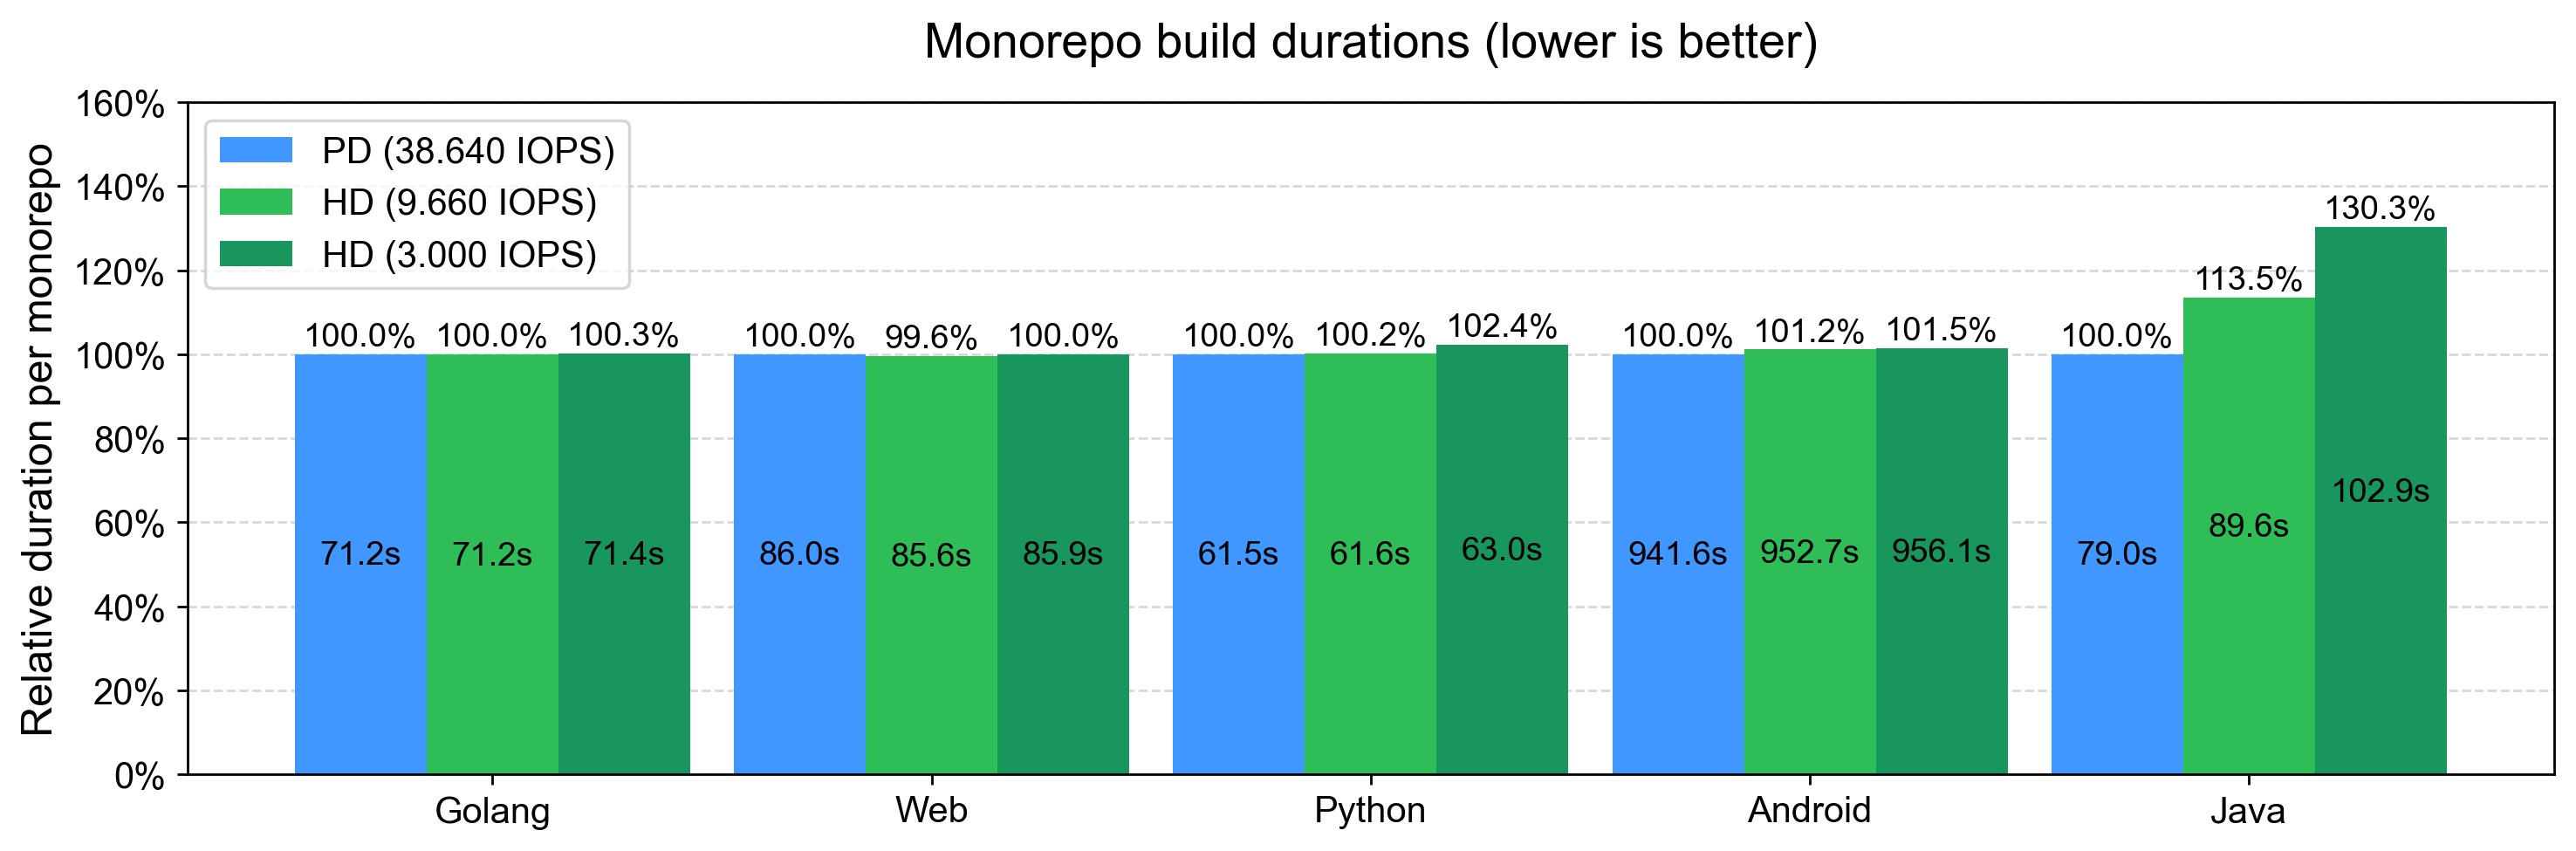

In [3]:
ax: plt.Axes
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(14, 4), dpi=250)

w = 0.3

plt.title("Monorepo build durations (lower is better)", pad=15, size=16)
ax.set_axisbelow(True)

# x axis
cases = np.arange(len(df.columns))
ax.set_xticks(cases, df.columns)

# y axis
yticks = range(0, 161, 20)
ax.set_yticks(yticks, labels=[str(i) + '%' for i in yticks])
ax.set_ylabel("Relative duration per monorepo", size=14)
ax.set_ylim(0, 160)
ax.grid(axis='y', which='major', visible=True, linestyle='--', color='grey', alpha=0.3)

# bars
ax.bar(cases - w, df_relative.loc['pd'], w, label='PD (38.640 IOPS)', color=colors['pd'])
ax.bar(cases - 0.0, df_relative.loc['hd-eq'], w, label='HD (9.660 IOPS)', color=colors['hd'])
ax.bar(cases + w, df_relative.loc['hd-min'], w, label='HD (3.000 IOPS)', color='#18965e')
ax.legend(loc='upper left')

for i, case in enumerate(df.columns):
    kw = { 'color': 'black', 'horizontalalignment': 'center', 'size': 11 }
    df_case = df.loc[:, case]
    df_case_rel = df_relative.loc[:, case]

    # percentages
    ax.text(i - w, df_case_rel['pd'] + 2, str(round(df_case_rel['pd'], 1)) + '%', **kw)
    ax.text(i - 0.0, df_case_rel['hd-eq'] + 2, str(round(df_case_rel['hd-eq'], 1)) + '%', **kw)
    ax.text(i + w, df_case_rel['hd-min'] + 2, str(round(df_case_rel['hd-min'], 1)) + '%', **kw)

    # absolute values
    ax.text(i - w, df_case_rel['pd'] / 2, str(round(df_case['pd'], 1)) + 's', **kw)
    ax.text(i - 0.0, df_case_rel['hd-eq'] / 2, str(round(df_case['hd-eq'], 1)) + 's', **kw)
    ax.text(i + w, df_case_rel['hd-min'] / 2, str(round(df_case['hd-min'], 1)) + 's', **kw)

ax.margins(0.05, 0.075)
plt.show()